# Question 2 — Descriptive Analysis of 311 Adoption

Produces three outputs:
- `results/figures/fig_adoption_timing.png` — Exhibit 1: diffusion timeline
- `results/figures/fig_adoption_region.png` — Exhibit 2: regional adoption rates
- `results/tables/tab_adopter_summary.tex/.csv` — Table 1: adopter vs. non-adopter characteristics

Input: `data_clean/city_311_analysis.csv` (301 rows, output of step4_analytical_sample.ipynb)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

CLEAN   = '../data_clean/'
FIGURES = '../results/figures/'
TABLES  = '../results/tables/'

Path(FIGURES).mkdir(parents=True, exist_ok=True)
Path(TABLES).mkdir(parents=True, exist_ok=True)

# Publication-quality style
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

## Load data and create derived variables

In [2]:
df = pd.read_csv(CLEAN + 'city_311_analysis.csv', dtype={'GEOID': str})
print(f'Loaded: {len(df)} rows')
print('\nadoption_status:')
print(df['adoption_status'].value_counts().to_string())

# Census region
REGION_MAP = {
    **{s: 'Northeast' for s in ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']},
    **{s: 'Midwest'   for s in ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']},
    **{s: 'South'     for s in ['DE','FL','GA','MD','NC','SC','VA','WV','DC',
                                 'AL','KY','MS','TN','AR','LA','OK','TX']},
    **{s: 'West'      for s in ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']},
}
df['region'] = df['state_abbr'].map(REGION_MAP)

df['ever_adopt'] = df['adoption_status'].map(
    {'adopted': 1, 'adopted_unknown_year': 1, 'not_adopted': 0}
)

unmapped = df[df['region'].isna()]['state_abbr'].unique()
assert len(unmapped) == 0, f'Unmapped states: {unmapped}'

print('\nRegion distribution:')
print(df['region'].value_counts().to_string())

Loaded: 301 rows

adoption_status:
adoption_status
adopted_unknown_year    148
adopted                  99
not_adopted              54

Region distribution:
region
West         124
South        104
Midwest       46
Northeast     27


## Exhibit 1 — Timing of 311 diffusion

Sample: `adoption_status == 'adopted'` with non-null `adoption_year_clean` (99 cities).  
Chart: bars = new adopters per year (left axis); line = cumulative adopters (right axis).

Timing sample : 99 cities  (1996–2025)
Unknown-year  : 148 cities (annotated but excluded from chart)


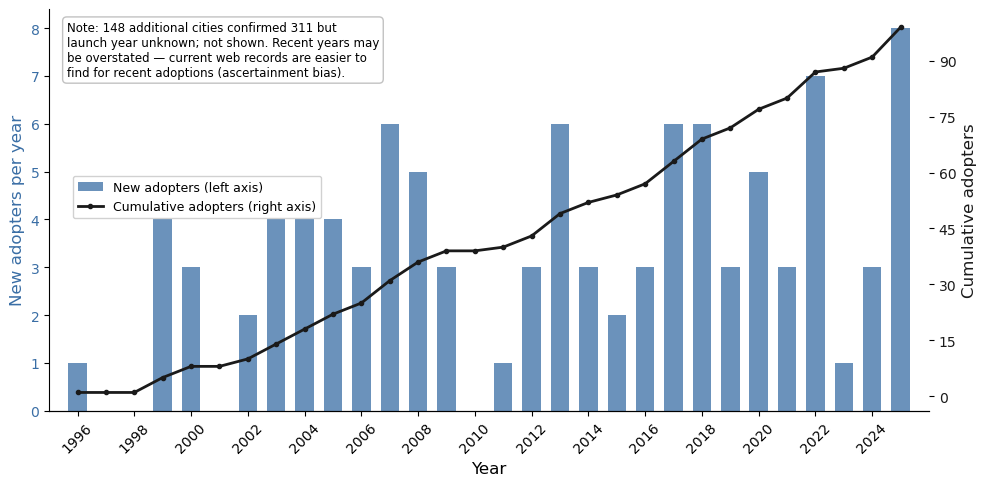

Saved fig_adoption_timing.png


In [3]:
# --- Build timing data ---
timing = df[(df['adoption_status'] == 'adopted') & df['adoption_year_clean'].notna()].copy()
timing['year'] = timing['adoption_year_clean'].astype(int)

n_timing   = len(timing)
n_unknown  = (df['adoption_status'] == 'adopted_unknown_year').sum()
year_min, year_max = timing['year'].min(), timing['year'].max()

by_year = timing.groupby('year').size().rename('n_new').reset_index()
all_years = pd.DataFrame({'year': range(year_min, year_max + 1)})
by_year = all_years.merge(by_year, on='year', how='left').fillna(0)
by_year['n_new'] = by_year['n_new'].astype(int)
by_year['cumulative'] = by_year['n_new'].cumsum()

print(f'Timing sample : {n_timing} cities  ({year_min}–{year_max})')
print(f'Unknown-year  : {n_unknown} cities (annotated but excluded from chart)')

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)

bar_color  = '#3A6EA5'
line_color = '#1a1a1a'

ax1.bar(by_year['year'], by_year['n_new'],
        color=bar_color, alpha=0.75, width=0.65, zorder=2,
        label='New adopters (left axis)')

ax2.plot(by_year['year'], by_year['cumulative'],
         color=line_color, linewidth=2, marker='o', markersize=3, zorder=3,
         label='Cumulative adopters (right axis)')

ax1.set_xlabel('Year')
ax1.set_ylabel('New adopters per year', color=bar_color)
ax2.set_ylabel('Cumulative adopters',   color=line_color)
ax1.tick_params(axis='y', labelcolor=bar_color)
ax2.tick_params(axis='y', labelcolor=line_color)
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax1.set_xlim(year_min - 1, year_max + 1)
ax1.set_xticks(range(year_min, year_max + 1, 2))
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Two-line annotation: unknown-year caveat + ascertainment bias caveat
annotation = (
    f'Note: {n_unknown} additional cities confirmed 311 but\n'
    f'launch year unknown; not shown. Recent years may\n'
    f'be overstated — current web records are easier to\n'
    f'find for recent adoptions (ascertainment bias).'
)
ax1.text(
    0.02, 0.97,
    annotation,
    transform=ax1.transAxes, va='top', ha='left', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
              edgecolor='#bbbbbb', alpha=0.9)
)

# Combined legend from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9,
           bbox_to_anchor=(0.02, 0.60), framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES + 'fig_adoption_timing.png')
plt.show()
print('Saved fig_adoption_timing.png')

## Exhibit 2 — Regional adoption rates

Sample: all 301 cities.  
Chart: horizontal stacked bar, shares within each Census region, three segments.

Region counts:
adoption_status  adopted  adopted_unknown_year  not_adopted
region                                                     
West                  28                    62           34
South                 39                    51           14
Midwest               18                    24            4
Northeast             14                    11            2

Region shares:
adoption_status  adopted  adopted_unknown_year  not_adopted
region                                                     
West               0.226                 0.500        0.274
South              0.375                 0.490        0.135
Midwest            0.391                 0.522        0.087
Northeast          0.519                 0.407        0.074


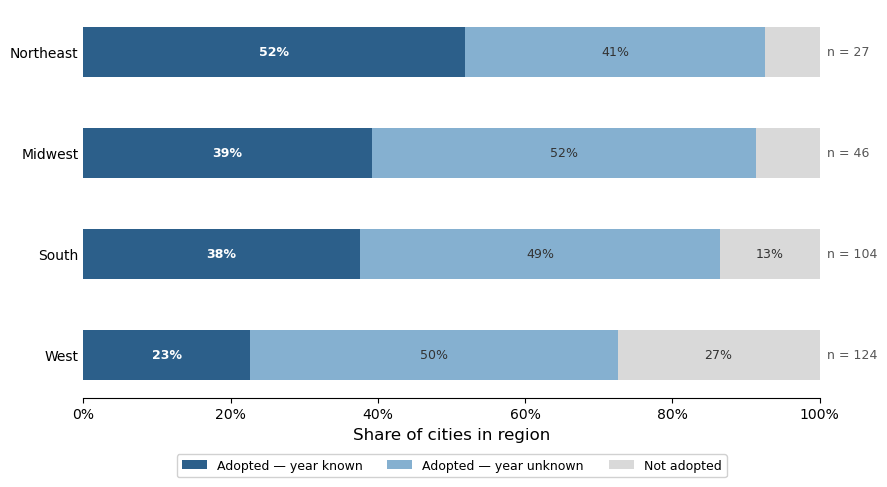

Saved fig_adoption_region.png


In [5]:
# --- Build regional data ---
counts = (
    df.groupby(['region', 'adoption_status'])
    .size()
    .reset_index(name='n')
)
pivot = counts.pivot(index='region', columns='adoption_status', values='n').fillna(0)

for col in ['adopted', 'adopted_unknown_year', 'not_adopted']:
    if col not in pivot.columns:
        pivot[col] = 0.0

region_totals = pivot.sum(axis=1)
share = pivot.div(region_totals, axis=0)

# Order bottom-to-top for horizontal bar
region_order = ['West', 'South', 'Midwest', 'Northeast']
share  = share.loc[region_order]
pivot  = pivot.loc[region_order]

print('Region counts:')
print(pivot.astype(int).to_string())
print('\nRegion shares:')
print(share.round(3).to_string())

# --- Plot ---
COL_ORDER  = ['adopted', 'adopted_unknown_year', 'not_adopted']
COLORS     = {'adopted': '#2c5f8a', 'adopted_unknown_year': '#85b0d0', 'not_adopted': '#d9d9d9'}
LABEL_MAP  = {
    'adopted':              'Adopted — year known',
    'adopted_unknown_year': 'Adopted — year unknown',
    'not_adopted':          'Not adopted',
}

fig, ax = plt.subplots(figsize=(9, 5))
lefts = np.zeros(len(region_order))

for col in COL_ORDER:
    vals = share[col].values
    ax.barh(region_order, vals, left=lefts,
            color=COLORS[col], label=LABEL_MAP[col], height=0.5)

    # Label segments >= 10%
    for i, (v, left) in enumerate(zip(vals, lefts)):
        if v >= 0.10:
            txt_color = 'white' if col == 'adopted' else '#333333'
            ax.text(left + v / 2, i, f'{v:.0%}',
                    ha='center', va='center', fontsize=9, color=txt_color,
                    fontweight='bold' if col == 'adopted' else 'normal')
    lefts += vals

# N labels at right margin
for i, region in enumerate(region_order):
    n = int(region_totals.loc[region])
    ax.text(1.01, i, f'n = {n}', va='center', ha='left', fontsize=9, color='#555555',
            transform=ax.get_yaxis_transform())

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Share of cities in region')
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES + 'fig_adoption_region.png')
plt.show()
print('Saved fig_adoption_region.png')

## Table 1 — Adopters vs. non-adopters: summary characteristics

Rows: N, mean pop, median pop, % in each Census region.  
Columns: Not adopted | Adopted (year known) | Adopted (year unknown) | All.

In [5]:
# --- Compute statistics ---
groups = {
    'not_adopted':          df[df['adoption_status'] == 'not_adopted'],
    'adopted':              df[df['adoption_status'] == 'adopted'],
    'adopted_unknown_year': df[df['adoption_status'] == 'adopted_unknown_year'],
    'All':                  df,
}

rows = {}

rows['N'] = {g: len(v) for g, v in groups.items()}

rows['Mean population (000s)'] = {
    g: v['pop_2020'].mean() / 1_000 for g, v in groups.items()
}
rows['Median population (000s)'] = {
    g: v['pop_2020'].median() / 1_000 for g, v in groups.items()
}

for region in ['Northeast', 'Midwest', 'South', 'West']:
    rows[f'  {region} (%)'] = {
        g: (v['region'] == region).sum() / len(v) * 100
        for g, v in groups.items()
    }

col_order = ['not_adopted', 'adopted', 'adopted_unknown_year', 'All']
table = pd.DataFrame(rows).T[col_order]

print(table.round(1).to_string())

                          not_adopted  adopted  adopted_unknown_year    All
N                                54.0     99.0                 148.0  301.0
Mean population (000s)          235.8    497.1                 176.1  292.4
Median population (000s)        150.3    210.9                 137.6  155.2
  Northeast (%)                   3.7     14.1                   7.4    9.0
  Midwest (%)                     7.4     18.2                  16.2   15.3
  South (%)                      25.9     39.4                  34.5   34.6
  West (%)                       63.0     28.3                  41.9   41.2


In [6]:
# --- Format and save ---

COL_HEADERS = {
    'not_adopted':          'Not adopted',
    'adopted':              'Adopted\n(year known)',
    'adopted_unknown_year': 'Adopted\n(year unknown)',
    'All':                  'All cities',
}

def fmt_cell(val, stat):
    if stat == 'N':
        return str(int(round(val)))
    if 'population' in stat.lower():
        return f'{val:,.0f}'
    return f'{val:.1f}'

# Save CSV (rounded)
csv_out = table.copy()
csv_out.index.name = 'Statistic'
csv_out.columns = [COL_HEADERS[c].replace('\n', ' ') for c in col_order]
csv_out.round(1).to_csv(TABLES + 'tab_adopter_summary.csv')
print('Saved tab_adopter_summary.csv')

# Build LaTeX
header = ' & '.join(COL_HEADERS[c].replace('\n', ' ') for c in col_order)

latex_lines = [
    r'\begin{tabular}{lrrrr}',
    r'\toprule',
    f'& {header} \\\\',
    r'\midrule',
]

for stat, row in table.iterrows():
    stat_latex = stat.replace('%', r'\%')   # escape % in row label
    cells = ' & '.join(fmt_cell(row[c], stat) for c in col_order)
    if '(%)' in stat:
        cells = ' & '.join(
            f'{fmt_cell(row[c], stat)}\\%' for c in col_order
        )
    latex_lines.append(f'{stat_latex} & {cells} \\\\')
    if stat == 'N' or stat == 'Median population (000s)':
        latex_lines.append(r'\midrule')

latex_lines += [
    r'\bottomrule',
    r'\end{tabular}',
]

latex_str = '\n'.join(latex_lines)

with open(TABLES + 'tab_adopter_summary.tex', 'w') as f:
    f.write(latex_str)

print('Saved tab_adopter_summary.tex')
print()
print(latex_str)

Saved tab_adopter_summary.csv
Saved tab_adopter_summary.tex

\begin{tabular}{lrrrr}
\toprule
& Not adopted & Adopted (year known) & Adopted (year unknown) & All cities \\
\midrule
N & 54 & 99 & 148 & 301 \\
\midrule
Mean population (000s) & 236 & 497 & 176 & 292 \\
Median population (000s) & 150 & 211 & 138 & 155 \\
\midrule
  Northeast (\%) & 3.7\% & 14.1\% & 7.4\% & 9.0\% \\
  Midwest (\%) & 7.4\% & 18.2\% & 16.2\% & 15.3\% \\
  South (\%) & 25.9\% & 39.4\% & 34.5\% & 34.6\% \\
  West (\%) & 63.0\% & 28.3\% & 41.9\% & 41.2\% \\
\bottomrule
\end{tabular}


In [7]:
# --- Final summary ---
print('=== QUESTION 2 COMPLETE ===')
print(f'  Timing sample   : {n_timing} cities with confirmed formal-311 year')
print(f'  Unknown-year    : {n_unknown} confirmed-311 cities excluded from timing chart')
print(f'  Cross-section   : {len(df)} cities (all adoption_status values)')
print()
print('Output files:')
for f_path in [
    FIGURES + 'fig_adoption_timing.png',
    FIGURES + 'fig_adoption_region.png',
    TABLES  + 'tab_adopter_summary.tex',
    TABLES  + 'tab_adopter_summary.csv',
]:
    exists = Path(f_path).exists()
    print(f'  {f_path}  {"OK" if exists else "MISSING"}')

=== QUESTION 2 COMPLETE ===
  Timing sample   : 99 cities with confirmed formal-311 year
  Unknown-year    : 148 confirmed-311 cities excluded from timing chart
  Cross-section   : 301 cities (all adoption_status values)

Output files:
  ../results/figures/fig_adoption_timing.png  OK
  ../results/figures/fig_adoption_region.png  OK
  ../results/tables/tab_adopter_summary.tex  OK
  ../results/tables/tab_adopter_summary.csv  OK
